# Разработка модели для сервиса «Не бит, не крашен»

Цель: построить модель которая определяет рыночную стоимость автомобилей.

План:

1) Предобработка данных

2) Подготовка выборок

3) Обучение разных моделей

4) Анализ время обучения, время предсказания и качество моделей

5) Выбор лучшей модели

# Предобработка данных

In [158]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import time
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import phik
import matplotlib.pyplot as plt

In [159]:
autos = pd.read_csv('https://code.s3.yandex.net/datasets/autos.csv')
autos.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [160]:
autos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

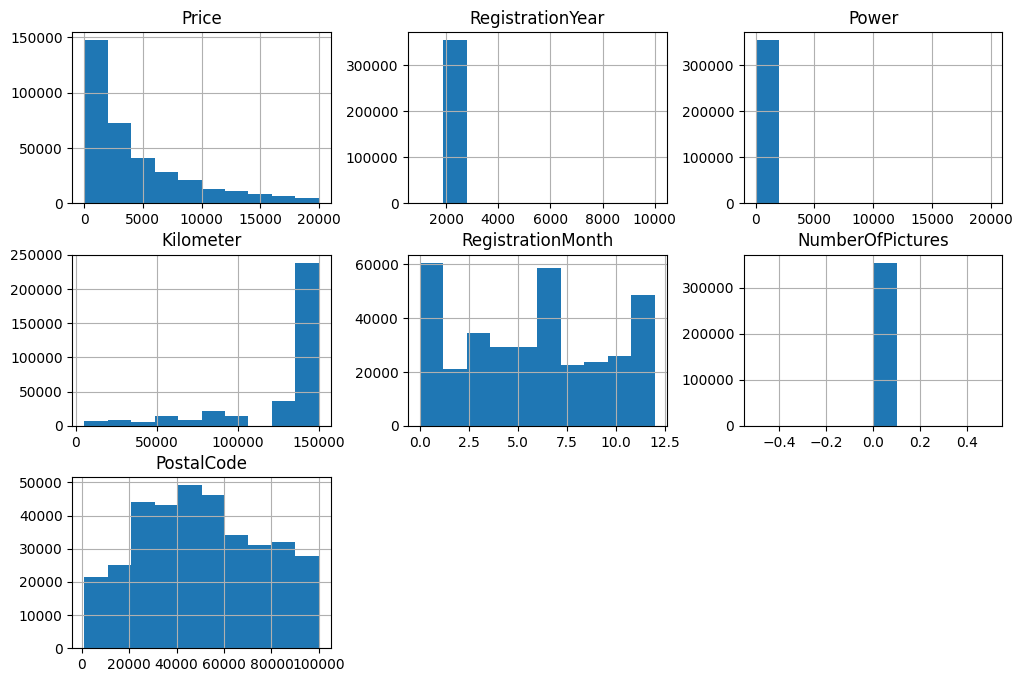

In [161]:
autos.hist(figsize=(12, 8));

In [162]:
autos.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

In [163]:
print('Средняя стоимость автомобиля без типа кузова:', autos[autos['VehicleType'].isna()]['Price'].mean())
print('Средняя стоимость автомобиля с типом кузова:', autos[autos['VehicleType'].notna()]['Price'].mean())

Средняя стоимость автомобиля без типа кузова: 2375.427954121099
Средняя стоимость автомобиля с типом кузова: 4658.154850905235


In [164]:
autos.loc[autos['VehicleType'].isna(),'VehicleType'] = 'unknown'
autos['VehicleType'].isna().sum()

np.int64(0)

<div class="alert alert-info">

<b>Заполнение пропусков в типе кузова:</b> 

Было принято решение создать категорию "unknown" так как стоимость авто без типа авто в 2 раза меньше чем с типом авто и удаление привело бы к смещению модели

In [165]:
print('Средняя стоимость автомобиля без типа коробки передач:', autos[autos['Gearbox'].isna()]['Price'].mean())
print('Средняя стоимость автомобиля с типом коробки передач', autos[autos['Gearbox'].notna()]['Price'].mean())

Средняя стоимость автомобиля без типа коробки передач: 2206.311904401755
Средняя стоимость автомобиля с типом коробки передач 4547.6972911734465


In [166]:
autos.loc[autos['Gearbox'].isna(),'Gearbox'] = 'unknown'
autos['Gearbox'].isna().sum()

np.int64(0)

<div class="alert alert-info">

<b>Заполнение пропусков в типе коробки передач:</b> 

Было принято решение создать категорию "unknown" так как стоимость авто без типа коробки передач в 2 раза меньше чем с типом коробки передач и удаление привело бы к смещению модели

In [167]:
print('Средняя стоимость автомобиля без модели:', autos[autos['Model'].isna()]['Price'].mean())
print('Средняя стоимость автомобиля с моделью', autos[autos['Model'].notna()]['Price'].mean())


Средняя стоимость автомобиля без модели: 2927.3550367926923
Средняя стоимость автомобиля с моделью 4504.346789615854


In [168]:
autos.loc[autos['Model'].isna(),'Model'] = 'unknown'
autos['Model'].isna().sum()

np.int64(0)

<div class="alert alert-info">

<b>Заполнение пропусков в модели авто:</b> 

Было принято решение создать категорию "unknown" так как стоимость авто без модели в 1.5 раза меньше чем с моделью и удаление привело бы к смещению модели

In [169]:
print('Средняя стоимость автомобиля без типа топлива:', autos[autos['FuelType'].isna()]['Price'].mean())
print('Средняя стоимость автомобиля с типом топлива', autos[autos['FuelType'].notna()]['Price'].mean())

Средняя стоимость автомобиля без типа топлива: 2340.6399452804376
Средняя стоимость автомобиля с типом топлива 4629.086314911937


In [170]:
autos.loc[autos['FuelType'].isna(),'FuelType'] = 'unknown'
autos['FuelType'].isna().sum()

np.int64(0)

In [171]:
# Проверим уникальные значения FuelType
print('Уникальные значения FuelType:')
print(autos['FuelType'].value_counts())

Уникальные значения FuelType:
FuelType
petrol      216352
gasoline     98720
unknown      32895
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: count, dtype: int64


In [172]:
# Объединяем 'petrol' и 'gasoline' - это одно и то же (бензин)
# petrol - британский английский, gasoline - американский английский
autos['FuelType'] = autos['FuelType'].replace('petrol', 'gasoline')

print('После объединения:')
print(autos['FuelType'].value_counts())

После объединения:
FuelType
gasoline    315072
unknown      32895
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: count, dtype: int64


<div class="alert alert-info">

<b>Комментарий студента V2:</b>

Исправлено: объединил 'petrol' и 'gasoline' в одну категорию, так как это одно и то же (бензин на разных языках). 'petrol' - британский английский, 'gasoline' - американский английский.

</div>

<div class="alert alert-info">

<b>Заполнение пропусков в типе топлива:</b> 

Было принято решение создать категорию "unknown" так как стоимость авто без типа топлива в 2 раза меньше чем с типом топлива и удаление привело бы к смещению модели

In [173]:
print('Средняя стоимость автомобиля без указания ремонта:', autos[autos['Repaired'].isna()]['Price'].mean())
print('Средняя стоимость автомобиля с указанием ремонта', autos[autos['Repaired'].notna()]['Price'].mean())

Средняя стоимость автомобиля без указания ремонта: 2626.4192455800094
Средняя стоимость автомобиля с указанием ремонта 4866.4301325847855


In [174]:
autos.loc[autos['Repaired'].isna(),'Repaired'] = 'unknown'
autos['Repaired'].isna().sum()

np.int64(0)

<div class="alert alert-info">

<b>Заполнение пропусков в указании ремонта:</b> 

Было принято решение создать категорию "unknown" так как стоимость авто без указания ремонта в 1.5 раза меньше чем с указанием ремонта и удаление привело бы к смещению модели

In [175]:
autos.isna().sum()

DateCrawled          0
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Kilometer            0
RegistrationMonth    0
FuelType             0
Brand                0
Repaired             0
DateCreated          0
NumberOfPictures     0
PostalCode           0
LastSeen             0
dtype: int64

<div class="alert alert-info">

<b>Вывод по пропускам:</b> 

Было принято решение создавать категорию "unknown" для пропусков в данных, так как стоимость авто без указания данных в 1.5 раза меньше чем с указанием данных и удаление привело бы к смещению модели

In [176]:
autos.duplicated().sum()

np.int64(4)

In [177]:
autos.drop_duplicates(inplace=True)
autos.duplicated().sum()

np.int64(0)

<div class="alert alert-info">

Дубликаты удалены

array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'RegistrationYear'}>,
        <Axes: title={'center': 'Power'}>],
       [<Axes: title={'center': 'Kilometer'}>,
        <Axes: title={'center': 'RegistrationMonth'}>,
        <Axes: title={'center': 'NumberOfPictures'}>],
       [<Axes: title={'center': 'PostalCode'}>, <Axes: >, <Axes: >]],
      dtype=object)

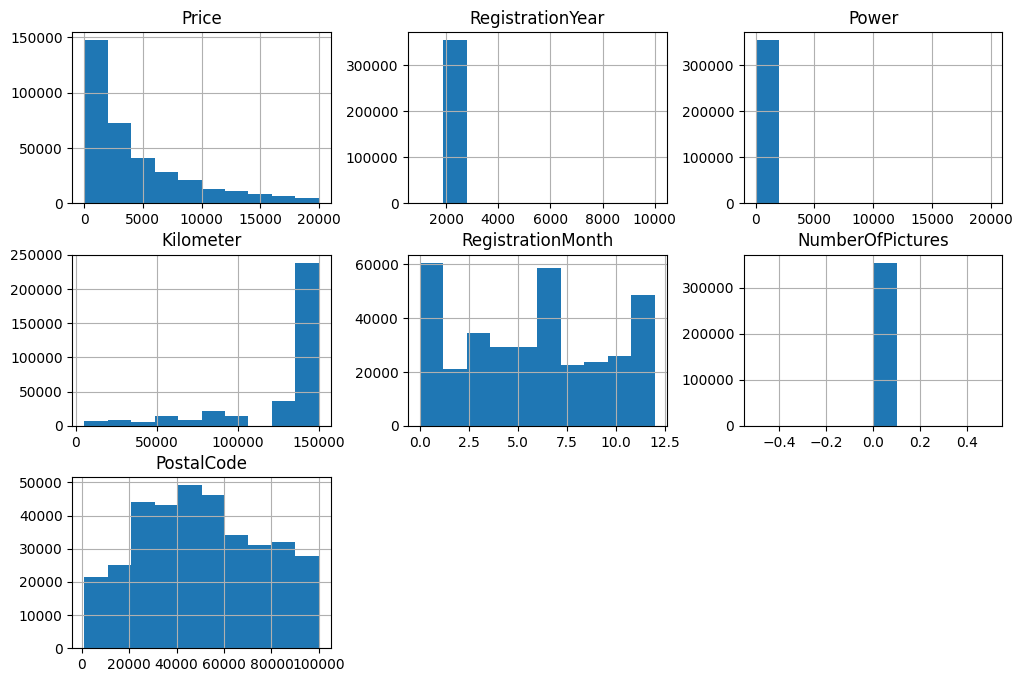

In [178]:
autos.hist(figsize=(12, 8))

count    354365.000000
mean       4416.679830
std        4514.176349
min           0.000000
25%        1050.000000
50%        2700.000000
75%        6400.000000
max       20000.000000
Name: Price, dtype: float64

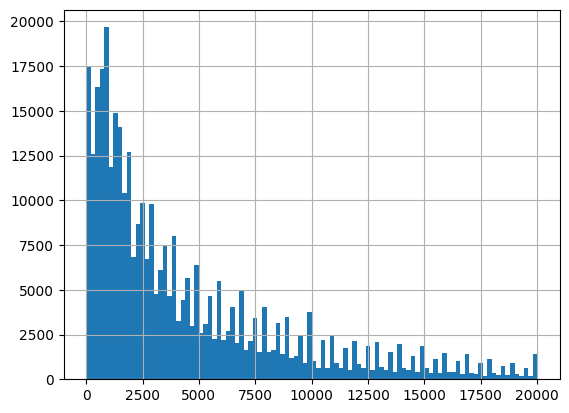

In [179]:
autos['Price'].hist(bins=100)
autos['Price'].describe()

In [180]:
print(
'Количество машин со стоимостью меньше 10:', autos[autos['Price'] < 10]['Price'].count(), '\n'
'Количество машин со стоимостью меньше 100:', autos[autos['Price'] < 100]['Price'].count(), '\n'
'Количество машин со стоимостью меньше 200:', autos[autos['Price'] < 200]['Price'].count(), '\n'
'Количество машин со стоимостью меньше 500:', autos[autos['Price'] < 500]['Price'].count(), '\n'
'Количество машин со стоимостью 20000(максимальной):', autos[autos['Price'] == 20000]['Price'].count())

Количество машин со стоимостью меньше 10: 12028 
Количество машин со стоимостью меньше 100: 13314 
Количество машин со стоимостью меньше 200: 17462 
Количество машин со стоимостью меньше 500: 36054 
Количество машин со стоимостью 20000(максимальной): 268


In [181]:
autos = autos[autos['Price'] > 500]
print('Количество машин со стоимостью меньше 500:', autos[autos['Price'] < 500]['Price'].count())
autos['Price'].describe()

Количество машин со стоимостью меньше 500: 0


count    312641.000000
mean       4974.823881
std        4521.813632
min         501.000000
25%        1500.000000
50%        3300.000000
75%        6999.000000
max       20000.000000
Name: Price, dtype: float64

<div class="alert alert-info">

<b>Вывод по аномальной стоимостью авто:</b> 

Было принято решение удалить 10% аномальных цен(<500) от общего количества

count    312641.000000
mean       2004.225127
std          64.356577
min        1000.000000
25%        2000.000000
50%        2004.000000
75%        2008.000000
max        9999.000000
Name: RegistrationYear, dtype: float64

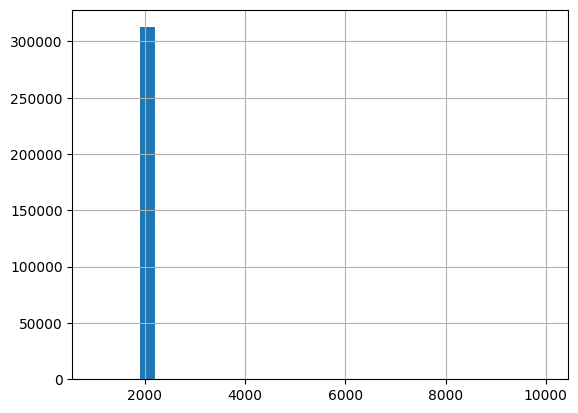

In [182]:
autos['RegistrationYear'].hist(bins=30)
autos['RegistrationYear'].describe()

<Axes: >

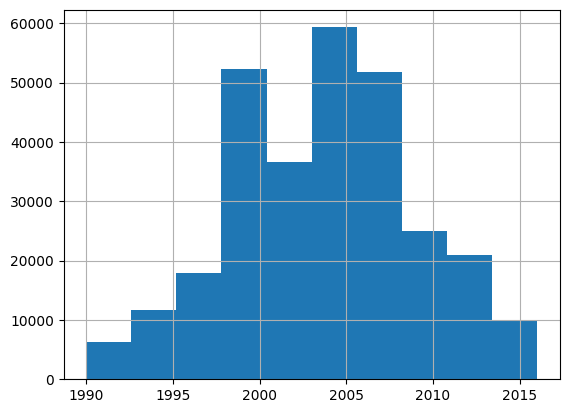

In [183]:
autos = autos[(autos['RegistrationYear'] >= 1990) & (autos['RegistrationYear'] <= 2016)].reset_index(drop=True)
autos['RegistrationYear'].hist()


<div class="alert alert-info">

<b>Вывод по аномальному году выпуска авто:</b> 

Было принято решение удалить авто <1990 года и >2016(даты сбора данных)

count    291660.000000
mean        117.447000
std         183.541267
min           0.000000
25%          75.000000
50%         110.000000
75%         150.000000
max       20000.000000
Name: Power, dtype: float64

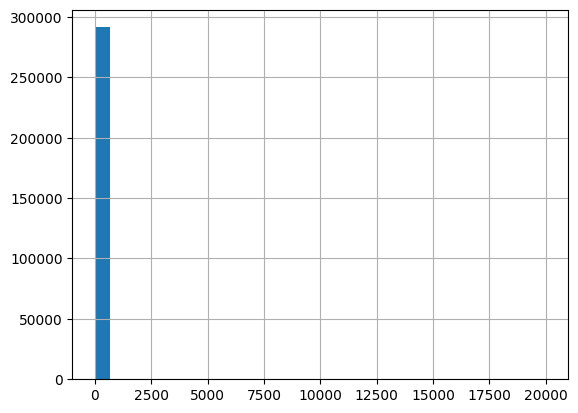

In [184]:
autos['Power'].hist(bins=30)
autos['Power'].describe()

count    267343.000000
mean        123.298815
std          51.373162
min          36.000000
25%          84.000000
50%         116.000000
75%         150.000000
max         349.000000
Name: Power, dtype: float64

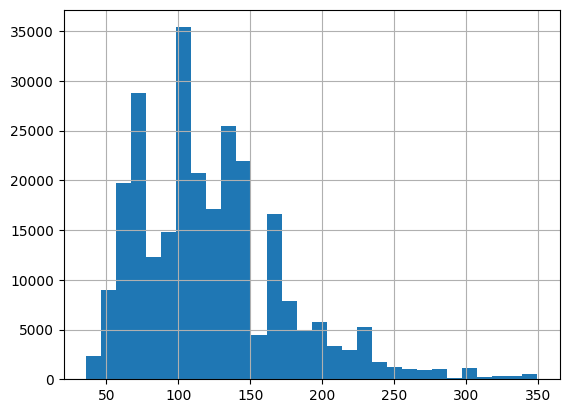

In [185]:
autos[(autos['Power'] > 35) & (autos['Power'] < 350)]['Power'].hist(bins=30)
autos = autos[(autos['Power'] > 35) & (autos['Power'] < 350)].reset_index(drop=True)
autos['Power'].describe()


<div class="alert alert-info">

<b>Вывод по аномальной мощности авто:</b> 

Было принято решение удалить авто с мощностью <35 л.с. и >350 л.с., std уменьшилось с 180 до 50

count    267343.000000
mean     127894.726999
std       36646.593543
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: Kilometer, dtype: float64

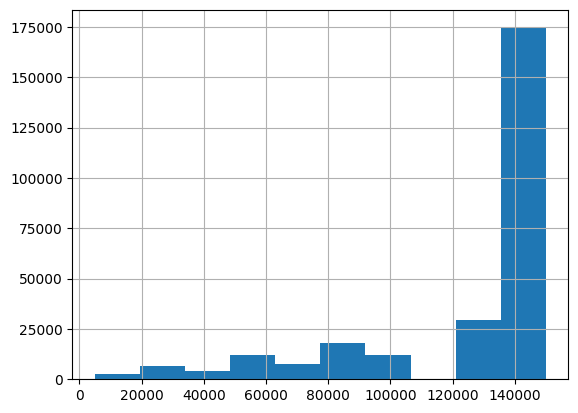

In [186]:
autos['Kilometer'].hist()
autos['Kilometer'].describe()

In [187]:
print(
'Количество машин с пробегом > 125000:', autos[autos['Kilometer'] > 125000].shape[0], '\n'
'Количество машин с пробегом = 150000:', autos[autos['Kilometer'] == 150000].shape[0])

Количество машин с пробегом > 125000: 174866 
Количество машин с пробегом = 150000: 174866


<div class="alert alert-info">

<b>Вывод по пробегу авто:</b> 

Пробег авто >125000 указывается как 150000, данные трогать не стоит, так как это 50% от общего количества

In [188]:
autos = autos.drop(columns=['DateCrawled',
                            'DateCreated',
                            'LastSeen', 
                            'NumberOfPictures',
                            'PostalCode',
                            'RegistrationMonth'])

print('Удалены неинформативные данные для модели')

Удалены неинформативные данные для модели


<div class="alert alert-info">

<b>Вывод по неинформативным данным:</b> 

'DateCrawled', 'DateCreated', 'LastSeen', 'NumberOfPictures', 'PostalCode', 'RegistrationMonth' - данные данные не влияют на стоимость авто

In [189]:
print('Финальный размер датасета:', autos.shape)
print('\nСтолбцы:', autos.columns.tolist())
print('\nПропуски:\n', autos.isna().sum())
autos.info()

Финальный размер датасета: (267343, 10)

Столбцы: ['Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model', 'Kilometer', 'FuelType', 'Brand', 'Repaired']

Пропуски:
 Price               0
VehicleType         0
RegistrationYear    0
Gearbox             0
Power               0
Model               0
Kilometer           0
FuelType            0
Brand               0
Repaired            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267343 entries, 0 to 267342
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Price             267343 non-null  int64 
 1   VehicleType       267343 non-null  object
 2   RegistrationYear  267343 non-null  int64 
 3   Gearbox           267343 non-null  object
 4   Power             267343 non-null  int64 
 5   Model             267343 non-null  object
 6   Kilometer         267343 non-null  int64 
 7   FuelType          267343 non-null  object
 8  

# Проверка мультиколлинеарности категориальных признаков

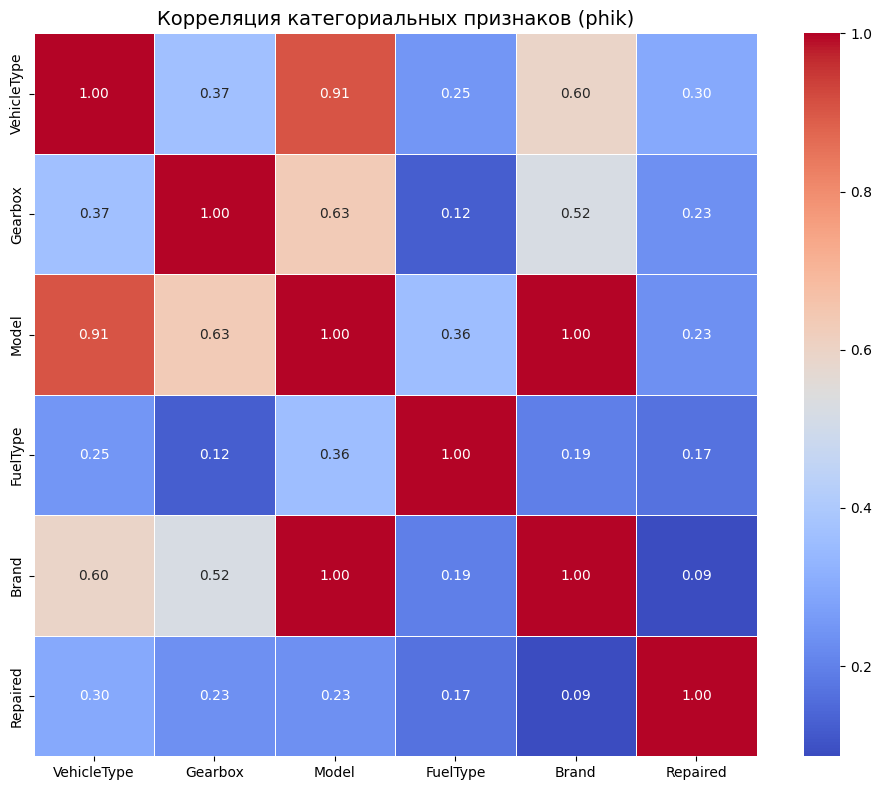


Корреляционная матрица phik:
             VehicleType  Gearbox  Model  FuelType  Brand  Repaired
VehicleType        1.000    0.366  0.905     0.248  0.595     0.297
Gearbox            0.366    1.000  0.632     0.124  0.524     0.233
Model              0.905    0.632  1.000     0.358  0.998     0.235
FuelType           0.248    0.124  0.358     1.000  0.195     0.168
Brand              0.595    0.524  0.998     0.195  1.000     0.086
Repaired           0.297    0.233  0.235     0.168  0.086     1.000


In [190]:
# Выберем категориальные признаки для анализа
categorical_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'Repaired']

# Рассчитаем корреляционную матрицу phik
phik_matrix = autos[categorical_cols].phik_matrix()

# Визуализируем
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Корреляция категориальных признаков (phik)', fontsize=14)
plt.tight_layout()
plt.show()

print('\nКорреляционная матрица phik:')
print(phik_matrix.round(3))

In [191]:
# Найдем пары признаков с высокой корреляцией (> 0.7)
high_corr_threshold = 0.7

print('Пары признаков с высокой корреляцией (> 0.7):')
print('='*60)

for i in range(len(phik_matrix.columns)):
    for j in range(i+1, len(phik_matrix.columns)):
        corr_value = phik_matrix.iloc[i, j]
        if corr_value > high_corr_threshold:
            col1 = phik_matrix.columns[i]
            col2 = phik_matrix.columns[j]
            print(f'{col1} <-> {col2}: {corr_value:.3f}')
            
print('\nЕсли корреляция высокая, можно удалить один из признаков для ускорения обучения.')

Пары признаков с высокой корреляцией (> 0.7):
VehicleType <-> Model: 0.905
Model <-> Brand: 0.998

Если корреляция высокая, можно удалить один из признаков для ускорения обучения.


In [192]:
# Удаляем Brand, так как он сильно коррелирует с Model (0.998)
# Model содержит более детальную информацию и позволяет определить бренд
autos = autos.drop(columns=['Brand'])

print('Столбец Brand удален.')
print(f'Текущие столбцы: {autos.columns.tolist()}')

Столбец Brand удален.
Текущие столбцы: ['Price', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model', 'Kilometer', 'FuelType', 'Repaired']


<div class="alert alert-info">

<b>Комментарий студента V2:</b>

Исправлено: добавлена проверка мультиколлинеарности для категориальных признаков с помощью библиотеки phik. 

**Результат анализа:**
- VehicleType <-> Model: корреляция 0.905
- **Model <-> Brand: корреляция 0.998** (очень высокая!)

**Решение:** Удален столбец Brand, так как он практически полностью коррелирует с Model (0.998). Model содержит более детальную информацию и позволяет определить бренд. Это устранит мультиколлинеарность для линейных моделей и ускорит обучение.

</div>

<div class="alert alert-info">

## Итоги предобработки данных:

**Исходный датасет:** 354369 записей, 16 столбцов  
**После обработки:** 267343 записей, 9 столбцов

**Проведённая работа:**

1. **Обработка пропусков:** Все пропуски заполнены категорией "unknown" (VehicleType, Gearbox, Model, FuelType, Repaired), так как средняя стоимость автомобилей с пропусками была в 1.5-2 раза ниже, и удаление привело бы к смещению модели.

2. **Удаление дубликатов:** Найдено и удалено 4 дубликата.

3. **Объединение скрытых дубликатов:** В столбце FuelType объединены 'petrol' и 'gasoline' в одну категорию (бензин на разных языках).

4. **Обработка аномалий:**
   - **Price:** удалены автомобили стоимостью < 500 евро (~10% данных)
   - **RegistrationYear:** оставлены автомобили 1990-2016 годов (год сбора данных)
   - **Power:** оставлена мощность от 35 до 350 л.с., стандартное отклонение уменьшилось с 180 до 50
   - **Kilometer:** данные не изменялись, так как 150000 км - технический лимит (~50% данных)

5. **Удаление неинформативных признаков:** Удалены 6 столбцов (DateCrawled, DateCreated, LastSeen, NumberOfPictures, PostalCode, RegistrationMonth), которые не влияют на рыночную стоимость автомобиля.

6. **Устранение мультиколлинеарности:** Удален столбец Brand (корреляция с Model = 0.998), так как Model содержит более детальную информацию.

**Итого удалено:** ~87000 записей (~25% данных) - в основном за счёт аномалий в году регистрации и мощности.

**Данные готовы для обучения модели.**
</div>

# Подготовка выборок

In [193]:
X = autos.drop(columns=['Price'])
y = autos['Price']

# Сначала разделим на train+validation и test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Затем train разделим на train и validation (80/20 от оставшихся 80%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} записей ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} записей ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} записей ({X_test.shape[0]/len(X)*100:.1f}%)')

categorical_features = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired']
numerical_features = ['RegistrationYear', 'Power', 'Kilometer']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

print(f'\nРазмер X_train после кодирования: {X_train_encoded.shape}')
print(f'Размер X_val после кодирования: {X_val_encoded.shape}')
print(f'Размер X_test после кодирования: {X_test_encoded.shape}')

Train: 171099 записей (64.0%)
Validation: 42775 записей (16.0%)
Test: 53469 записей (20.0%)

Размер X_train после кодирования: (171099, 268)
Размер X_val после кодирования: (42775, 268)
Размер X_test после кодирования: (53469, 268)


<div class="alert alert-info">

**Итоги подготовки выборок:**

Данные разделены на train/validation/test (64%/16%/20%):
- **Train:** для обучения моделей
- **Validation:** для выбора лучшей модели и подбора гиперпараметров
- **Test:** для финального тестирования только лучшей модели

Применены трансформации:
- OHE для категориальных признаков (5 столбцов) с устранением dummy-ловушки (drop='first')
- StandardScaler для числовых признаков (3 столбца)

Данные готовы для обучения.
</div>

# Обучение разных моделей

In [194]:
def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):
    """
    Обучает модель и возвращает метрики
    """
    print(f'Обучение {model_name}...')
    
    # Замер времени обучения
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train
    
    # Замер времени предсказания
    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred
    
    # Расчет RMSE
    rmse = (mean_squared_error(y_test, y_pred) ** 0.5)
    
    # Вывод результатов
    print(f'  Время обучения: {train_time:.2f} сек')
    print(f'  Время предсказания: {pred_time:.4f} сек')
    print(f'  RMSE: {rmse:.2f}')
    print(f'  Требование RMSE < 2500: {"✓ PASS" if rmse < 2500 else "✗ FAIL"}')
    print()
    
    return {
        'model_name': model_name,
        'train_time': train_time,
        'pred_time': pred_time,
        'rmse': rmse
    }

# Словарь для хранения результатов
results = {}

In [195]:
# Обучаем модели на train, тестируем на validation
# Test выборку НЕ используем - она только для финального тестирования!

# 1. LinearRegression
results['LinearRegression'] = train_and_evaluate(
    LinearRegression(),
    'LinearRegression',
    X_train_encoded, y_train,
    X_val_encoded, y_val  # Validation вместо test!
)

# 2. Ridge
results['Ridge'] = train_and_evaluate(
    Ridge(alpha=1.0, random_state=42),
    'Ridge',
    X_train_encoded, y_train,
    X_val_encoded, y_val  # Validation вместо test!
)

# 3. RandomForest
results['RandomForest'] = train_and_evaluate(
    RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'RandomForest',
    X_train_encoded, y_train,
    X_val_encoded, y_val  # Validation вместо test!
)

# 4. LightGBM
results['LightGBM'] = train_and_evaluate(
    LGBMRegressor(n_estimators=100, max_depth=10, random_state=42, verbose=-1),
    'LightGBM',
    X_train_encoded, y_train,
    X_val_encoded, y_val  # Validation вместо test!
)

Обучение LinearRegression...
  Время обучения: 0.64 сек
  Время предсказания: 0.0004 сек
  RMSE: 2321.10
  Требование RMSE < 2500: ✓ PASS

Обучение Ridge...
  Время обучения: 0.19 сек
  Время предсказания: 0.0004 сек
  RMSE: 2321.71
  Требование RMSE < 2500: ✓ PASS

Обучение RandomForest...
  Время обучения: 7.18 сек
  Время предсказания: 0.0420 сек
  RMSE: 1846.58
  Требование RMSE < 2500: ✓ PASS

Обучение LightGBM...
  Время обучения: 0.58 сек
  Время предсказания: 0.0297 сек
  RMSE: 1684.70
  Требование RMSE < 2500: ✓ PASS



/Users/sotnikov/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [196]:
# Создаем таблицу с результатами
results_df = pd.DataFrame(results).T
print('Сравнение моделей:')
print(results_df.to_string())


Сравнение моделей:
                        model_name train_time pred_time         rmse
LinearRegression  LinearRegression   0.642598  0.000365  2321.096724
Ridge                        Ridge   0.187855   0.00036   2321.71037
RandomForest          RandomForest   7.180407   0.04202  1846.576593
LightGBM                  LightGBM   0.580767  0.029656  1684.696331


# Подбор гиперпараметров для LightGBM

In [197]:
# Тестируем разные гиперпараметры LightGBM на validation

# Вариант 1: Больше деревьев и глубины
results['LightGBM_v2'] = train_and_evaluate(
    LGBMRegressor(n_estimators=200, max_depth=15, random_state=42, verbose=-1),
    'LightGBM (n_est=200, depth=15)',
    X_train_encoded, y_train,
    X_val_encoded, y_val  # Validation!
)

# Вариант 2: Меньший learning_rate, больше деревьев
results['LightGBM_v3'] = train_and_evaluate(
    LGBMRegressor(n_estimators=300, max_depth=10, learning_rate=0.05, random_state=42, verbose=-1),
    'LightGBM (n_est=300, lr=0.05)',
    X_train_encoded, y_train,
    X_val_encoded, y_val  # Validation!
)

# Вариант 3: Больше листьев
results['LightGBM_v4'] = train_and_evaluate(
    LGBMRegressor(n_estimators=150, max_depth=10, num_leaves=50, random_state=42, verbose=-1),
    'LightGBM (n_est=150, leaves=50)',
    X_train_encoded, y_train,
    X_val_encoded, y_val  # Validation!
)

Обучение LightGBM (n_est=200, depth=15)...


/Users/sotnikov/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Время обучения: 1.16 сек
  Время предсказания: 0.0814 сек
  RMSE: 1601.62
  Требование RMSE < 2500: ✓ PASS

Обучение LightGBM (n_est=300, lr=0.05)...


/Users/sotnikov/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Время обучения: 1.66 сек
  Время предсказания: 0.0913 сек
  RMSE: 1640.23
  Требование RMSE < 2500: ✓ PASS

Обучение LightGBM (n_est=150, leaves=50)...
  Время обучения: 1.20 сек
  Время предсказания: 0.0508 сек
  RMSE: 1614.69
  Требование RMSE < 2500: ✓ PASS



/Users/sotnikov/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [198]:
# Обновляем таблицу с результатами всех моделей
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('rmse')
print('Сравнение всех моделей (отсортировано по RMSE):')
print(results_df.to_string())
print('\n' + '='*80)
print(f'\nЛучшая модель: {results_df.iloc[0]["model_name"]}')
print(f'RMSE: {results_df.iloc[0]["rmse"]:.2f}')
print(f'Время обучения: {results_df.iloc[0]["train_time"]:.2f} сек')
print(f'Время предсказания: {results_df.iloc[0]["pred_time"]:.4f} сек')

Сравнение всех моделей (отсортировано по RMSE):
                                       model_name train_time pred_time         rmse
LightGBM_v2        LightGBM (n_est=200, depth=15)   1.157651  0.081437  1601.621061
LightGBM_v4       LightGBM (n_est=150, leaves=50)   1.201071   0.05081  1614.689306
LightGBM_v3         LightGBM (n_est=300, lr=0.05)   1.656263  0.091336  1640.226375
LightGBM                                 LightGBM   0.580767  0.029656  1684.696331
RandomForest                         RandomForest   7.180407   0.04202  1846.576593
LinearRegression                 LinearRegression   0.642598  0.000365  2321.096724
Ridge                                       Ridge   0.187855   0.00036   2321.71037


Лучшая модель: LightGBM (n_est=200, depth=15)
RMSE: 1601.62
Время обучения: 1.16 сек
Время предсказания: 0.0814 сек


# Финальное тестирование лучшей модели на test выборке

In [199]:
# Лучшая модель на validation: LightGBM (n_est=200, depth=15)
# Теперь протестируем её на test выборке (которую модель НЕ видела!)

print('='*80)
print('ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА TEST ВЫБОРКЕ')
print('='*80)
print('\nОбучаем лучшую модель на train и тестируем на test...\n')

best_model = LGBMRegressor(n_estimators=200, max_depth=15, random_state=42, verbose=-1)

# Обучаем на train
import time
start_train = time.time()
best_model.fit(X_train_encoded, y_train)
train_time = time.time() - start_train

# Предсказываем на test
start_pred = time.time()
y_test_pred = best_model.predict(X_test_encoded)
pred_time = time.time() - start_pred

# Рассчитываем RMSE на test
test_rmse = (mean_squared_error(y_test, y_test_pred) ** 0.5)

print(f'Модель: LightGBM (n_estimators=200, max_depth=15)')
print(f'Время обучения: {train_time:.2f} сек')
print(f'Время предсказания: {pred_time:.4f} сек')
print(f'RMSE на test выборке: {test_rmse:.2f}')
print(f'Требование RMSE < 2500: {"✓ PASS" if test_rmse < 2500 else "✗ FAIL"}')
print('\n' + '='*80)

ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА TEST ВЫБОРКЕ

Обучаем лучшую модель на train и тестируем на test...

Модель: LightGBM (n_estimators=200, max_depth=15)
Время обучения: 1.22 сек
Время предсказания: 0.1047 сек
RMSE на test выборке: 1574.18
Требование RMSE < 2500: ✓ PASS



/Users/sotnikov/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# Общий вывод